# Week 5 EDA Mini-Project — One Clean Data Story

## Project Summary

This project is a complete Exploratory Data Analysis mini-project using a cars fuel efficiency dataset.

The main goal is to understand how different car features affect fuel efficiency. In this dataset, fuel efficiency is measured using MPG, which means miles per gallon. A higher MPG means the car is more fuel efficient.

The main question I want to answer is:

**Do heavier and more powerful cars have lower fuel efficiency?**

To answer this question, I will clean the dataset, summarize the data, create charts, and write a conclusion based on the patterns I find.

## Part 1 — Learn: What Makes a Notebook a Data Story

### What turns a notebook from code into a data story

A notebook becomes a data story when it is not just a collection of code cells. It should have a clear question, a logical flow, clean visuals, and a conclusion.

If the notebook only has code and outputs, the reader may not understand what the purpose of the analysis is. A good data story explains what we are trying to find, why we are checking certain things, and what the results mean.

For this project, the main question is about fuel efficiency. I am trying to understand whether heavier and more powerful cars usually have lower MPG. This gives the notebook a clear direction.

---

### Why every analysis should answer “so what?”

In data analysis, it is not enough to only show numbers or charts. We also need to explain what those results mean.

For example, if I find that heavier cars have lower MPG, the “so what?” is that car weight is an important factor in fuel efficiency. This makes the analysis more useful because it gives meaning to the numbers.

A good analysis should help the reader understand the insight, not just the result.

---

### What makes a notebook readable

A readable notebook should be organized in a clear way. It should have markdown headings, short explanations between code cells, and clean chart titles and labels.

The reader should be able to follow the work from beginning to end without getting confused.

A good notebook usually includes:

* A short introduction
* A clear question
* Cleaning steps with explanations
* Summary statistics
* Visualizations
* Short insights after charts
* A final conclusion

This makes the notebook easier to understand, especially for someone who is not reading the code deeply.

---

### How a data scientist presents findings to someone non-technical

A data scientist should explain findings in simple language. Not everyone understands code, formulas, or technical terms, so the conclusion should focus on the meaning of the results.

For example, instead of only saying “weight has a negative correlation with MPG,” it is better to say:

**Heavier cars usually have lower fuel efficiency.**

This is easier to understand and more useful for a non-technical person.

Overall, a good data story should be clear, simple, and focused on the main insight.


## Dataset Introduction

For this project, I used a cars MPG dataset.

The dataset contains information about different cars, including:

- MPG
- Cylinders
- Displacement
- Horsepower
- Weight
- Acceleration
- Model year
- Origin
- Car name

I chose this dataset because it is beginner-friendly and easy to understand. It also has useful numeric columns that can help answer questions about fuel efficiency.

## Main Question

The main question for this project is:

**Do heavier and more powerful cars have lower fuel efficiency?**

To answer this question, I will mainly look at MPG, weight, horsepower, and cylinders. I will also check origin and model year to understand the dataset better.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the public cars MPG dataset
df = sns.load_dataset("mpg")

# Save the dataset as CSV so it can be uploaded to GitHub
df.to_csv("mpg_cars_dataset.csv", index=False)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Understanding the Dataset

Before cleaning or analyzing the data, I first checked the basic structure of the dataset. This helps me understand the number of rows and columns, data types, missing values, and the general content of the dataset.

In [32]:
# Checking the number of rows and columns
df.shape

(398, 9)

In [33]:
# Displaying the first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [34]:
# Checking column names
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [35]:
# Checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [36]:
# Checking missing values
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [37]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(0)

## Cleaning the Dataset

In this section, I cleaned the dataset before doing the analysis.

The main cleaning steps are:

- Handling missing values
- Removing duplicate rows
- Standardizing text columns
- Checking that important numeric columns are usable for analysis

In [38]:
# Creating a copy of the dataset before cleaning
df_cleaned = df.copy()

In [39]:
# Checking missing values before cleaning
print("Missing values before cleaning:")
print(df_cleaned.isnull().sum())

Missing values before cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [40]:
# Removing rows where horsepower is missing
# I removed these rows because horsepower is important for this analysis
df_cleaned = df_cleaned.dropna(subset=["horsepower"])

In [41]:
# Removing duplicate rows if any
df_cleaned = df_cleaned.drop_duplicates()

In [42]:
# Standardizing text columns
df_cleaned["origin"] = df_cleaned["origin"].str.strip().str.title()
df_cleaned["name"] = df_cleaned["name"].str.strip().str.title()

In [43]:
# Making sure horsepower is numeric
df_cleaned["horsepower"] = pd.to_numeric(df_cleaned["horsepower"], errors="coerce")

In [44]:
# Resetting the index after cleaning
df_cleaned = df_cleaned.reset_index(drop=True)

In [45]:
# Checking the dataset after cleaning
print("Missing values after cleaning:")
print(df_cleaned.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df_cleaned.duplicated().sum())

print("\nCleaned dataset shape:")
print(df_cleaned.shape)

Missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Duplicate rows after cleaning:
0

Cleaned dataset shape:
(392, 9)


### Cleaning Explanation

The dataset had some missing values in the horsepower column. Since horsepower is important for this project, I removed the rows where horsepower was missing.

I also checked for duplicate rows and removed them if any were present. After that, I cleaned the text columns such as `origin` and `name` by removing extra spaces and making the formatting more consistent.

This cleaning step is important because missing or inconsistent data can affect the accuracy of the analysis.

In [46]:
print("Before Cleaning:")
display(df.head())

print("After Cleaning:")
display(df_cleaned.head())

Before Cleaning:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


After Cleaning:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,Usa,Chevrolet Chevelle Malibu
1,15.0,8,350.0,165.0,3693,11.5,70,Usa,Buick Skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,Usa,Plymouth Satellite
3,16.0,8,304.0,150.0,3433,12.0,70,Usa,Amc Rebel Sst
4,17.0,8,302.0,140.0,3449,10.5,70,Usa,Ford Torino


## Analysis Section

In this section, I used summary statistics and grouping to understand the dataset better.

I used `.describe()` to summarize numeric columns, `.value_counts()` to count categories, and `.groupby()` to compare average MPG between different groups.

In [47]:
# Summary statistics for numeric columns
df_cleaned.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [48]:
# Count of cars by origin
df_cleaned["origin"].value_counts()

,count
origin,
Usa,245
Japan,79
Europe,68


In [49]:
# Average MPG by number of cylinders
avg_mpg_by_cylinders = df_cleaned.groupby("cylinders")["mpg"].mean()
avg_mpg_by_cylinders

,mpg
cylinders,
3,20.550000
4,29.283920
5,27.366667
6,19.973494
8,14.963107


In [50]:
# Average MPG by origin
avg_mpg_by_origin = df_cleaned.groupby("origin")["mpg"].mean()
avg_mpg_by_origin

,mpg
origin,
Europe,27.602941
Japan,30.450633
Usa,20.033469


In [51]:
# Average MPG by model year
avg_mpg_by_year = df_cleaned.groupby("model_year")["mpg"].mean()
avg_mpg_by_year.tail()

,mpg
model_year,
78,24.061111
79,25.093103
80,33.803704
81,30.185714
82,32.000000


## Correlation Check

Correlation helps to understand whether two numeric columns are related.

For this project, I checked how MPG is related to weight, horsepower, cylinders, displacement, acceleration, and model year.

In [52]:
numeric_columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

correlation = df_cleaned[numeric_columns].corr()
correlation

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


In [53]:
# Checking which numeric columns are most related to MPG
correlation["mpg"].sort_values(ascending=False)

,mpg
mpg,1.000000
model_year,0.580541
acceleration,0.423329
cylinders,-0.777618
horsepower,-0.778427
displacement,-0.805127
weight,-0.832244


From the correlation results, I can see which features are most related to MPG. A negative value means that when one feature increases, MPG usually decreases.

## Visualization Section

In this section, I created charts to support the main question.

Each chart includes a title and labels so that the result is easier to understand.

### Chart 1 — Weight vs MPG

This chart shows the relationship between car weight and MPG.

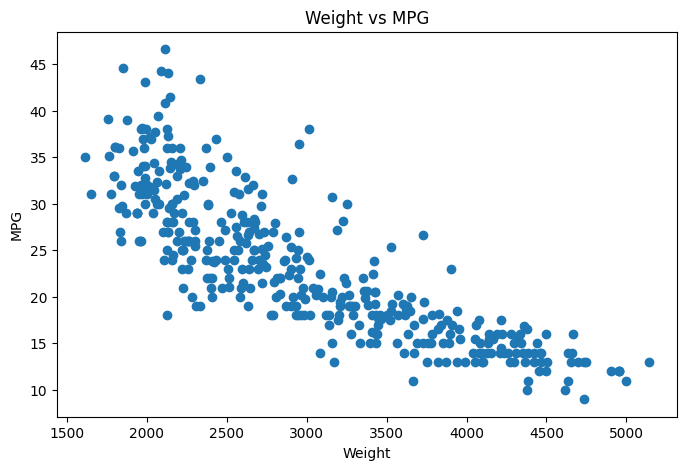

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(df_cleaned["weight"], df_cleaned["mpg"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

**Insight:** Heavier cars generally have lower MPG. This means heavier cars are usually less fuel efficient.

### Chart 2 — Average MPG by Cylinders

This chart compares the average MPG of cars with different numbers of cylinders.

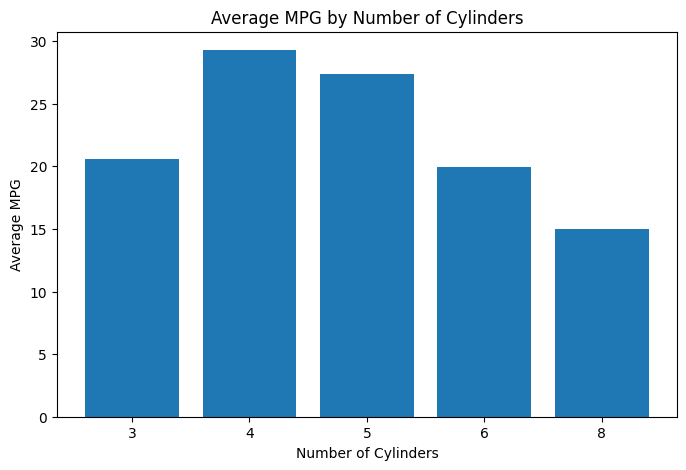

In [55]:
avg_mpg_by_cylinders = df_cleaned.groupby("cylinders")["mpg"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_mpg_by_cylinders.index.astype(str), avg_mpg_by_cylinders.values)
plt.xlabel("Number of Cylinders")
plt.ylabel("Average MPG")
plt.title("Average MPG by Number of Cylinders")
plt.show()

**Insight:** Cars with fewer cylinders usually have better fuel efficiency than cars with more cylinders.

### Chart 3 — Horsepower vs MPG

This chart shows the relationship between horsepower and MPG.

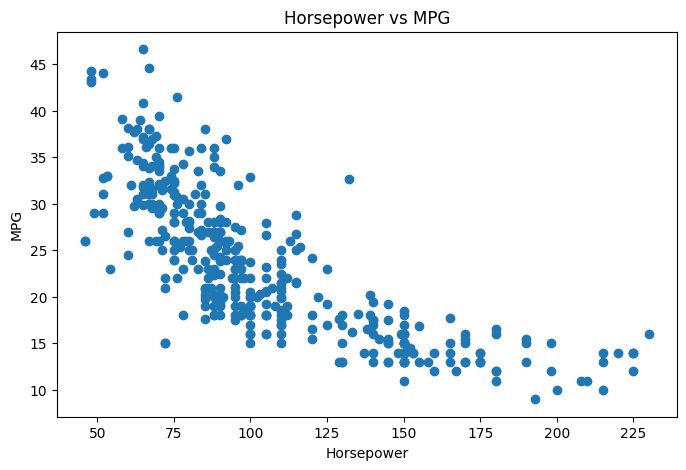

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(df_cleaned["horsepower"], df_cleaned["mpg"])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

**Insight:** Cars with higher horsepower usually have lower MPG. This shows that more powerful cars often use more fuel.

### Chart 4 — Average MPG by Origin

This chart compares the average MPG of cars from different origins.

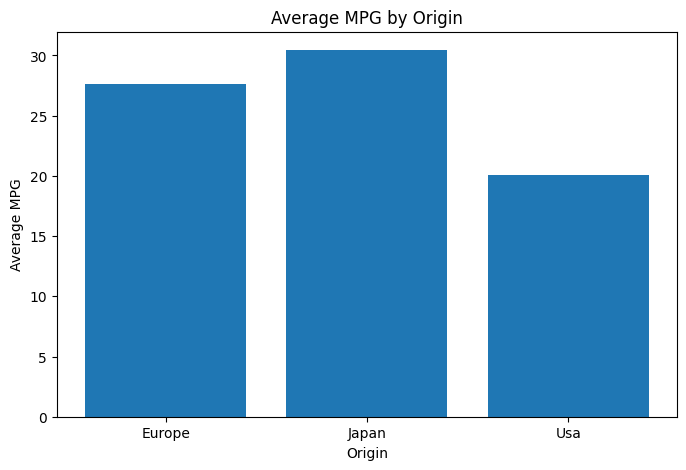

In [57]:
avg_mpg_by_origin = df_cleaned.groupby("origin")["mpg"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_mpg_by_origin.index, avg_mpg_by_origin.values)
plt.xlabel("Origin")
plt.ylabel("Average MPG")
plt.title("Average MPG by Origin")
plt.show()

**Insight:** Cars from different origins show different average MPG values, which means origin may also be related to fuel efficiency.

## Conclusion

From this EDA mini-project, I found three main findings:

1. **Heavier cars usually have lower fuel efficiency.**  
   The Weight vs MPG chart showed a clear downward pattern. As car weight increases, MPG usually decreases.

2. **Cars with more cylinders usually have lower average MPG.**  
   The bar chart showed that cars with fewer cylinders generally have better fuel efficiency than cars with more cylinders.

3. **Higher horsepower is also related to lower MPG.**  
   The Horsepower vs MPG chart showed that more powerful cars often have lower fuel efficiency.

Overall, the analysis shows that weight, cylinders, and horsepower are important factors that affect fuel efficiency.

## Follow-up Machine Learning Question

A future machine learning model could try to answer this question:

**Can we predict a car’s MPG based on its weight, horsepower, cylinders, displacement, and model year?**

This would be a useful next step because the EDA showed that these features are related to MPG.